In [1]:
import os
import random
import numpy as np
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,ConfusionMatrixDisplay, f1_score, roc_curve)


2026-06-02 08:42:22.654847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780389742.887429      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780389742.953850      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780389743.459928      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780389743.459984      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780389743.459988      23 computation_placer.cc:177] computation placer alr

In [2]:
import tensorflow as tf


gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {gpus}")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Using GPU: {gpus[0].name}")
else:
    print("No GPU found, running on CPU")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU: /physical_device:GPU:0


# Reconocimiento de audio

In [3]:
SR = 22050
N_FFT = 2048
HOP = 512
N_MELS = 128
MAX_LEN = 128
 
MEL_MATRIX = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=N_MELS,
    num_spectrogram_bins=N_FFT // 2 + 1,
    sample_rate=SR,
    lower_edge_hertz=0.0,
    upper_edge_hertz=SR / 2,
)

I0000 00:00:1780389772.421276      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# Creacion de Mel Spectogram

In [4]:
@tf.function(input_signature=[tf.TensorSpec(shape=[None], dtype=tf.float32)])
def tf_mel_spectrogram(waveform):
    stft = tf.signal.stft(
        waveform,
        frame_length=N_FFT,
        frame_step=HOP,
        fft_length=N_FFT,
        window_fn=tf.signal.hann_window,
    )
    power = tf.abs(stft) ** 2
    mel = tf.matmul(power, MEL_MATRIX)
    mel_db = 10.0 * (tf.math.log(mel + 1e-6) / tf.math.log(10.0))
    mel_db = mel_db - tf.reduce_max(mel_db) 
    mel_db = tf.maximum(mel_db, -80.0)
    mel_db = tf.transpose(mel_db)
    frames = tf.shape(mel_db)[1]
    mel_db = tf.cond(
        frames < MAX_LEN,
        lambda: tf.pad(mel_db, [[0, 0], [0, MAX_LEN - frames]],
                       constant_values=-80.0),    
        lambda: mel_db[:, :MAX_LEN],
    )
    mel_db.set_shape([N_MELS, MAX_LEN])
    mel_db = tf.ensure_shape(mel_db, [N_MELS, MAX_LEN])   # returns a tensor, safe to assign
    return mel_db
 
 
def extract_features(path):
    waveform, _ = librosa.load(path, sr=SR, mono=True)
    waveform, _ = librosa.effects.trim(waveform, top_db=30)   
    peak = np.max(np.abs(waveform))
    if peak > 0:
        waveform = waveform / peak                            
    if waveform.size < HOP:                                   
        raise ValueError("audio too short / empty")
    waveform = tf.convert_to_tensor(waveform, dtype=tf.float32)
    return tf_mel_spectrogram(waveform).numpy()

# Ceacion de divisones test, train, y split usando las divisones del dataset

In [5]:
AUDIO_EXTS = ('.wav', '.mp3', '.flac', '.ogg')
SPLITS = ('training', 'validation', 'testing')

BASE_DIR = '/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm'

def collect_all(base_dir):
    buckets = {s: {'real': [], 'fake': []} for s in SPLITS}
    for dirpath, _, filenames in os.walk(base_dir):
        low = dirpath.lower() + os.sep
        split = next((s for s in SPLITS if os.sep + s + os.sep in low), None)
        if split is None:
            continue
        if os.sep + 'real' + os.sep in low:
            label = 'real'
        elif os.sep + 'fake' + os.sep in low:
            label = 'fake'
        else:
            continue
        for fn in filenames:
            if fn.lower().endswith(AUDIO_EXTS):
                buckets[split][label].append(os.path.join(dirpath, fn))
    return buckets

buckets = collect_all(BASE_DIR)

train_real = buckets['training']['real'] + buckets['validation']['real']
train_fake = buckets['training']['fake'] + buckets['validation']['fake']

test_real_all = buckets['testing']['real'][:]
test_fake_all = buckets['testing']['fake'][:]
rng = random.Random(42)
rng.shuffle(test_real_all); rng.shuffle(test_fake_all)

hr, hf = len(test_real_all)//2, len(test_fake_all)//2
val_real,  test_real  = test_real_all[:hr], test_real_all[hr:]
val_fake,  test_fake  = test_fake_all[:hf], test_fake_all[hf:]
print(f"Train {len(train_real)}/{len(train_fake)} | Val {len(val_real)}/{len(val_fake)} | Test {len(test_real)}/{len(test_fake)}")


Train 32341/32325 | Val 1132/1185 | Test 1132/1185


In [6]:
feat = extract_features(train_real[0])
print(feat.shape, feat.dtype, float(feat.min()), float(feat.max()))

(128, 128) float32 -80.0 -1.5405769348144531


# Crear array de features por split

In [7]:
def build(real_paths, fake_paths):
    X, y = [], []
    for p in real_paths:
        try:
            X.append(extract_features(p)); y.append(1)   # 1 = real
        except Exception as e:
            print(f"Skipped {p}: {e}")
    for p in fake_paths:
        try:
            X.append(extract_features(p)); y.append(0)   # 0 = fake
        except Exception as e:
            print(f"Skipped {p}: {e}")
    X = np.array(X)[..., np.newaxis]   # (N, 128, 128, 1)  channel axis for Conv2D
    y = np.array(y)
    return X, y
 
 
X_train, y_train = build(train_real, train_fake)
X_val,   y_val   = build(val_real,   val_fake)
X_test,  y_test  = build(test_real,  test_fake)
 
print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")


Skipped /kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training/real/file15440.wav_16k.wav_norm.wav_mono.wav_silence.wav: zero-size array to reduction operation maximum which has no identity
Skipped /kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training/real/file11064.wav_16k.wav_norm.wav_mono.wav_silence.wav: zero-size array to reduction operation maximum which has no identity
Train:      (64664, 128, 128, 1)
Validation: (2317, 128, 128, 1)
Test:       (2317, 128, 128, 1)


# Crear data pipeline

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

STRETCH_MIN, STRETCH_MAX = 0.8, 1.2
FREQ_MASK_MAX, N_FREQ_MASKS = 16, 2
TIME_MASK_MAX, N_TIME_MASKS = 16, 2
NOISE_STD = 3.0      # Gaussian noise in dB; survives per-sample standardization (additive shifts don't)
MASK_VALUE = -80.0

def time_warp(spec, label):
    factor = tf.random.uniform([], STRETCH_MIN, STRETCH_MAX)
    new_t = tf.cast(tf.round(tf.cast(MAX_LEN, tf.float32) * factor), tf.int32)
    warped = tf.image.resize(spec, [N_MELS, new_t])
    def crop():
        start = (new_t - MAX_LEN) // 2
        return warped[:, start:start + MAX_LEN, :]
    def pad():
        return tf.pad(warped, [[0, 0], [0, MAX_LEN - new_t], [0, 0]], constant_values=MASK_VALUE)
    out = tf.cond(new_t >= MAX_LEN, crop, pad)
    out.set_shape([N_MELS, MAX_LEN, 1])
    return out, label

def _mask_axis(spec, axis_len, max_width, axis):
    w = tf.random.uniform([], 0, max_width + 1, dtype=tf.int32)
    start = tf.random.uniform([], 0, axis_len - w + 1, dtype=tf.int32)
    idx = tf.range(axis_len)
    keep = tf.logical_or(idx < start, idx >= start + w)
    keep = tf.reshape(keep, [axis_len, 1, 1] if axis == 0 else [1, axis_len, 1])
    keep = tf.cast(keep, spec.dtype)
    return spec * keep + (1.0 - keep) * MASK_VALUE

def spec_augment(spec, label):
    for _ in range(N_FREQ_MASKS):
        spec = _mask_axis(spec, N_MELS, FREQ_MASK_MAX, axis=0)
    for _ in range(N_TIME_MASKS):
        spec = _mask_axis(spec, MAX_LEN, TIME_MASK_MAX, axis=1)
    spec.set_shape([N_MELS, MAX_LEN, 1])
    return spec, label

def add_noise(spec, label):
    spec = spec + tf.random.normal(tf.shape(spec), stddev=NOISE_STD)
    spec.set_shape([N_MELS, MAX_LEN, 1])
    return spec, label

def augment(spec, label):
    spec, label = time_warp(spec, label)
    spec, label = spec_augment(spec, label)
    spec, label = add_noise(spec, label)
    return spec, label

In [9]:
BATCH_SIZE = 32

def make_train_ds(X, y):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.shuffle(buffer_size=len(X), reshuffle_each_iteration=True)
    ds = ds.map(augment, num_parallel_calls=AUTOTUNE)   # fresh aug each epoch
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)       # NO .cache() — keep aug random

def make_eval_ds(X, y):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    return ds.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_train_ds(X_train, y_train)   # augmented
val_ds   = make_eval_ds(X_val,   y_val)       # clean
test_ds  = make_eval_ds(X_test,  y_test)      # clean


# Creacion y entrenamiento del modelo

In [10]:
POOLS = 3
F = N_MELS // (2 ** POOLS)
T = MAX_LEN // (2 ** POOLS)
LAST_FILTERS = 128

## Modelo CNN + BiLSTM con 10 capas

### Z normalization

In [11]:
class PerSampleStandardization(layers.Layer):
    def call(self, x):
        mean = tf.reduce_mean(x, axis=[1, 2, 3], keepdims=True)
        std  = tf.math.reduce_std(x, axis=[1, 2, 3], keepdims=True)
        return (x - mean) / (std + 1e-6)

In [12]:
def build_model():
    model = keras.Sequential([
        keras.Input((N_MELS, MAX_LEN, 1)),
        PerSampleStandardization(),

        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(2), layers.SpatialDropout2D(0.1),

        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(2), layers.SpatialDropout2D(0.1),

        layers.Conv2D(LAST_FILTERS, 3, padding="same"),
        layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(2), layers.SpatialDropout2D(0.1),

        layers.Permute((2, 1, 3)),
        layers.Reshape((T, F * LAST_FILTERS)),

        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(32)),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ])
    return model

model = build_model()
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy",
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall"),
             keras.metrics.AUC(name="auc")],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ per_sample_standardization      │ (None, 128, 128, 1)    │             0 │
│ (PerSampleStandardization)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 64, 64, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 32, 32, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 16, 16, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 16, 128)        │     1,081,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,220,865 (4.66 MB)

 Trainable params: 1,220,417 (4.66 MB)

 Non-trainable params: 448 (1.75 KB)

## Pesos de clase para arregla desbalance en el dataset

In [13]:
classes, counts = np.unique(y_train, return_counts=True)
total = counts.sum()
class_weight = {int(c): float(total / (len(classes) * n)) for c, n in zip(classes, counts)}
print("class_weight:", class_weight)

class_weight: {0: 1.000216550657386, 1: 0.9997835430903862}


## Entrenamiento


In [14]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "checkpoint_{epoch}.keras")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_prefix,
        save_weights_only=False,
        save_freq="epoch",
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max",
        patience=5, restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-5,
    ),
]
 
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/40


E0000 00:00:1780391245.843232      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/spatial_dropout2d_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780391246.813092      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


2021/2021 ━━━━━━━━━━━━━━━━━━━━ 108s 46ms/step - accuracy: 0.8569 - auc: 0.9156 - loss: 0.4006 - precision: 0.8566 - recall: 0.8577 - val_accuracy: 0.6357 - val_auc: 0.9404 - val_loss: 0.7889 - val_precision: 0.5729 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/40
2021/2021 ━━━━━━━━━━━━━━━━━━━━ 92s 45ms/step - accuracy: 0.9483 - auc: 0.9851 - loss: 0.2283 - precision: 0.9515 - recall: 0.9447 - val_accuracy: 0.6565 - val_auc: 0.9290 - val_loss: 0.9807 - val_precision: 0.5873 - val_recall: 0.9982 - learning_rate: 1.0000e-04
Epoch 3/40
2021/2021 ━━━━━━━━━━━━━━━━━━━━ 92s 45ms/step - accuracy: 0.9712 - auc: 0.9943 - loss: 0.1826 - precision: 0.9734 - recall: 0.9685 - val_accuracy: 0.8058 - val_auc: 0.9438 - val_loss: 0.5270 - val_precision: 0.7223 - val_recall: 0.9788 - learning_rate: 1.0000e-04
Epoch 4/40
2021/2021 ━━━━━━━━━━━━━━━━━━━━ 93s 46ms/step - accuracy: 0.9788 - auc: 0.9964 - loss: 0.1669 - precision: 0.9817 - recall: 0.9756 - val_accuracy: 0.7704 - val_auc: 0.9326 - val_

# Evaluacion del modelo

In [15]:
test_metrics = model.evaluate(test_ds, return_dict=True)
print("Test:", test_metrics)

73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9315 - auc: 0.5073 - loss: 0.2696 - precision: 0.9171 - recall: 0.9908
Test: {'accuracy': 0.8139836192131042, 'auc': 0.9635692238807678, 'loss': 0.5284879207611084, 'precision': 0.7274497151374817, 'recall': 0.9902827143669128}


## Loss por epoca

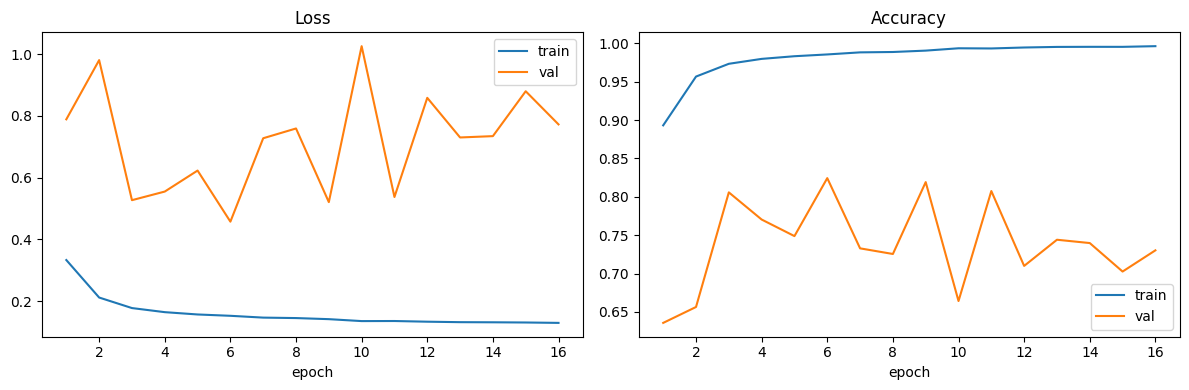

In [16]:
h = history.history
epochs = range(1, len(h["loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs, h["loss"], label="train")
ax[0].plot(epochs, h["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(epochs, h["accuracy"], label="train")
ax[1].plot(epochs, h["val_accuracy"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## Predicciones

In [17]:
y_true = np.concatenate([y.numpy() for _, y in test_ds]).astype(int)
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


## Precision / recall / F1 / accuracy

In [18]:
print(classification_report(y_true, y_pred, target_names=["fake (0)", "real (1)"], digits=4))
print(f"Macro F1: {f1_score(y_true, y_pred, average='macro'):.4f}")

              precision    recall  f1-score   support

    fake (0)     0.9858    0.6456    0.7802      1185
    real (1)     0.7274    0.9903    0.8388      1132

    accuracy                         0.8140      2317
   macro avg     0.8566    0.8179    0.8095      2317
weighted avg     0.8596    0.8140    0.8088      2317

Macro F1: 0.8095


In [19]:
ths = np.linspace(0.0, 1.0, 1001)
f1s = [f1_score(y_true, (y_prob >= t).astype(int), average="macro") for t in ths]
best_t = ths[int(np.argmax(f1s))]
print(f"Best threshold: {best_t:.4f} | macro-F1 there: {max(f1s):.4f}")

fpr, tpr, thr = roc_curve(y_true, y_prob)
fnr = 1 - tpr
i = np.nanargmin(np.abs(fnr - fpr))
print(f"EER: {(fpr[i]+fnr[i])/2:.4f} at threshold {thr[i]:.4f}")

print(classification_report(y_true, (y_prob >= best_t).astype(int),
                            target_names=["fake (0)", "real (1)"], digits=4))

Best threshold: 0.9490 | macro-F1 there: 0.9128
EER: 0.0919 at threshold 0.9529
              precision    recall  f1-score   support

    fake (0)     0.9241    0.9038    0.9138      1185
    real (1)     0.9016    0.9223    0.9118      1132

    accuracy                         0.9128      2317
   macro avg     0.9128    0.9130    0.9128      2317
weighted avg     0.9131    0.9128    0.9128      2317



## Matriz de confusion

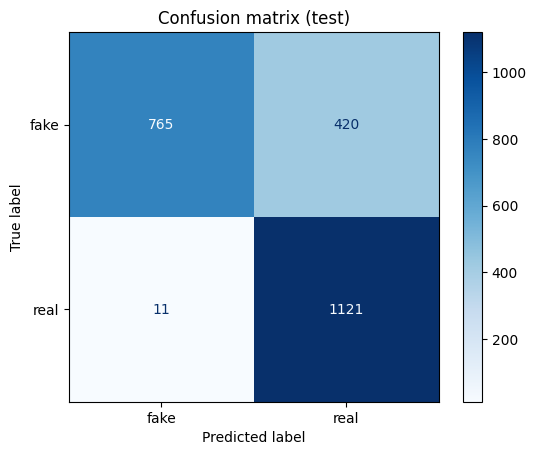

In [20]:
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["fake", "real"]).plot(
    cmap="Blues", values_format="d")
plt.title("Confusion matrix (test)")
plt.show()